In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df = df.rename(columns={
    "Sibsp": "No_Sibsp_onboard",
    "Parch": "No_Children_Siblings_onboard",
    "Ticket": "Ticket_number",
    "Fare": "Passenger_fare",
    "Cabin": "Cabin_no",
    "Embarked": "Port_of_Embarkation",
    "Pclass": "Ticket_class",
    "PassengerId": "Passenger_ID"
})

In [8]:
df.columns

Index(['Passenger_ID', 'Survived', 'Ticket_class', 'Name', 'Sex', 'Age',
       'SibSp', 'No_Children_Siblings_onboard', 'Ticket_number',
       'Passenger_fare', 'Cabin_no', 'Port_of_Embarkation'],
      dtype='object')

In [9]:
df.head()

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.isnull().sum()

Passenger_ID                      0
Survived                          0
Ticket_class                      0
Name                              0
Sex                               0
Age                             177
SibSp                             0
No_Children_Siblings_onboard      0
Ticket_number                     0
Passenger_fare                    0
Cabin_no                        687
Port_of_Embarkation               2
dtype: int64

In [12]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Passenger_ID,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Ticket_class,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
No_Children_Siblings_onboard,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket_number,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger_fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


Replacing the missing ages with the median age of the passengers

In [14]:
df["Age_missing"] = df["Age"].isna().astype(int)

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

Handling the missing values fo the cabin numbers

In [31]:
df["Cabin_missing"] = df["Cabin_no"].isna().astype(int)

In [32]:
df["Cabin_missing"].value_counts()

Cabin_missing
1    687
0    204
Name: count, dtype: int64

In [16]:
df.isnull().sum()

Passenger_ID                      0
Survived                          0
Ticket_class                      0
Name                              0
Sex                               0
Age                               0
SibSp                             0
No_Children_Siblings_onboard      0
Ticket_number                     0
Passenger_fare                    0
Cabin_no                        687
Port_of_Embarkation               2
Age_missing                       0
dtype: int64

In [33]:
pd.crosstab(
    df["Cabin_missing"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Cabin_missing,,
0,0.333333,0.666667
1,0.700146,0.299854


Handling Missing Port of Embarkation

In [34]:
df[df["Port_of_Embarkation"].isna()]

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation,Age_missing,Cabin_missing
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,0,0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,0,0


In [35]:
df[df["Ticket_number"] == "113572"]

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation,Age_missing,Cabin_missing
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,0,0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,0,0


In [36]:
df["Port_of_Embarkation"].mode()

0    S
Name: Port_of_Embarkation, dtype: object

Since the mode for the Port of embarkation is Port S we are going to replace the missing values with Port "S"

In [37]:
df["Port_of_Embarkation"] = df["Port_of_Embarkation"].fillna(
    df["Port_of_Embarkation"].mode()[0]
)

In [38]:
df["Port_of_Embarkation"].isna().sum()

0

In [39]:
df["Cabin_deck"] = df["Cabin_no"].str[0].fillna("Unknown")

In [40]:
df["Cabin_deck"].value_counts()

Cabin_deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [22]:
df["Sex"].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

In [23]:
df["Ticket_class"].value_counts()

Ticket_class
3    491
1    216
2    184
Name: count, dtype: int64

In [24]:
df["Port_of_Embarkation"].value_counts()

Port_of_Embarkation
S    644
C    168
Q     77
Name: count, dtype: int64

In [27]:
#Survival rate by sex
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [28]:
#Survival rate by ticket class
pd.crosstab(df["Ticket_class"], df["Survived"])

Survived,0,1
Ticket_class,,
1,80,136
2,97,87
3,372,119


In [30]:
#Survival rate by port of embarkation
pd.crosstab(df["Port_of_Embarkation"], df["Survived"])

Survived,0,1
Port_of_Embarkation,,
C,75,93
Q,47,30
S,427,217


In [41]:
pd.crosstab(
    df["Cabin_deck"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Cabin_deck,,
A,0.533333,0.466667
B,0.255319,0.744681
C,0.406780,0.593220
D,0.242424,0.757576
E,0.250000,0.750000
F,0.384615,0.615385
G,0.500000,0.500000
T,1.000000,0.000000
Unknown,0.700146,0.299854


In [43]:
df.head()

,Passenger_ID,Survived,Ticket_class,Name,Sex,Age,SibSp,No_Children_Siblings_onboard,Ticket_number,Passenger_fare,Cabin_no,Port_of_Embarkation,Age_missing,Cabin_missing,Cabin_deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,Unknown


Comparing Age groups against Survived & Died

In [44]:
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


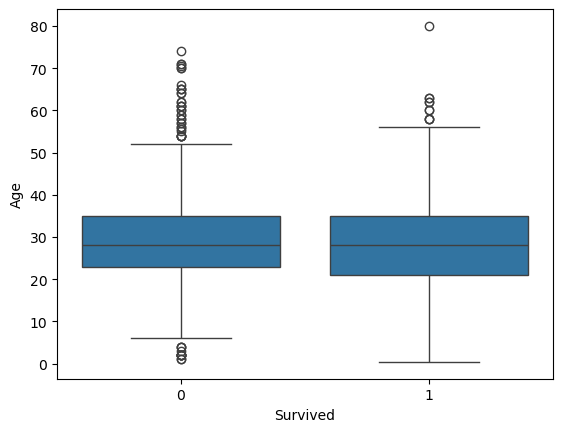

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Survived", y="Age")
plt.show()

In [48]:
df["Age_group"] = df["Age"].apply(
    lambda x: "Child" if x < 18 else "Adult"
)

pd.crosstab(
    df["Age_group"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Age_group,,
Adult,0.638817,0.361183
Child,0.460177,0.539823


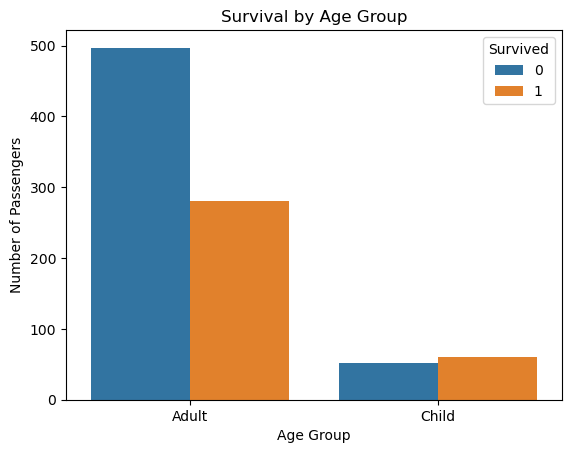

In [49]:
sns.countplot(data=df, x="Age_group", hue="Survived")
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.show()

Comparing Fare Vrs Survival

In [50]:
df.groupby("Survived")["Passenger_fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


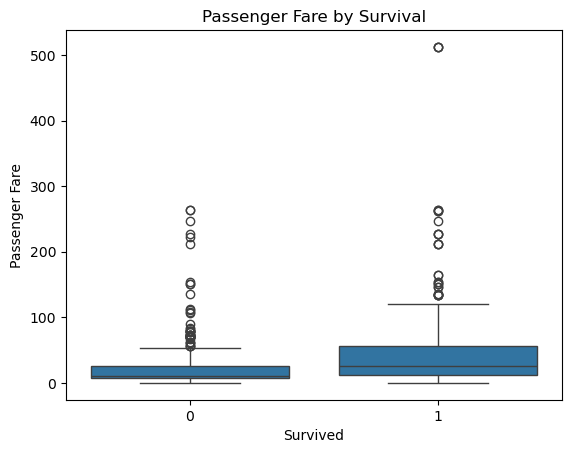

In [51]:
sns.boxplot(data=df, x="Survived", y="Passenger_fare")
plt.title("Passenger Fare by Survival")
plt.xlabel("Survived")
plt.ylabel("Passenger Fare")
plt.show()

In [53]:
#Checking whether fare price correlates with ticket class
df.groupby(["Ticket_class", "Survived"])["Passenger_fare"].median()

Ticket_class  Survived
1             0           44.7500
              1           77.9583
2             0           13.0000
              1           21.0000
3             0            8.0500
              1            8.5167
Name: Passenger_fare, dtype: float64

Comparing Family Size and Survival

In [54]:
df.groupby("Survived")["SibSp"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,0.553734,1.288399,0.0,0.0,0.0,1.0,8.0
1,342.0,0.473684,0.708688,0.0,0.0,0.0,1.0,4.0


In [55]:
pd.crosstab(
    df["SibSp"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
SibSp,,
0,0.654605,0.345395
1,0.464115,0.535885
2,0.535714,0.464286
3,0.750000,0.250000
4,0.833333,0.166667
5,1.000000,0.000000
8,1.000000,0.000000


No_Children_Siblings_onboard Vrs Survival

In [56]:
pd.crosstab(
    df["No_Children_Siblings_onboard"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
No_Children_Siblings_onboard,,
0,0.656342,0.343658
1,0.449153,0.550847
2,0.500000,0.500000
3,0.400000,0.600000
4,1.000000,0.000000
5,0.800000,0.200000
6,1.000000,0.000000


Creating a family size variable

In [57]:
df["Family_size"] = (
    df["SibSp"] +
    df["No_Children_Siblings_onboard"] +
    1
)

In [58]:
df.groupby("Survived")["Family_size"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,1.883424,1.830669,1.0,1.0,1.0,2.0,11.0
1,342.0,1.938596,1.186076,1.0,1.0,2.0,3.0,7.0


In [59]:
df["Family_size_group"] = pd.cut(
    df["Family_size"],
    bins=[0, 1, 4, 7, 11],
    labels=["Alone", "Small", "Medium", "Large"]
)

In [60]:
pd.crosstab(
    df["Family_size_group"],
    df["Survived"],
    normalize="index"
)

Survived,0,1
Family_size_group,,
Alone,0.696462,0.303538
Small,0.421233,0.578767
Medium,0.795918,0.204082
Large,1.000000,0.000000


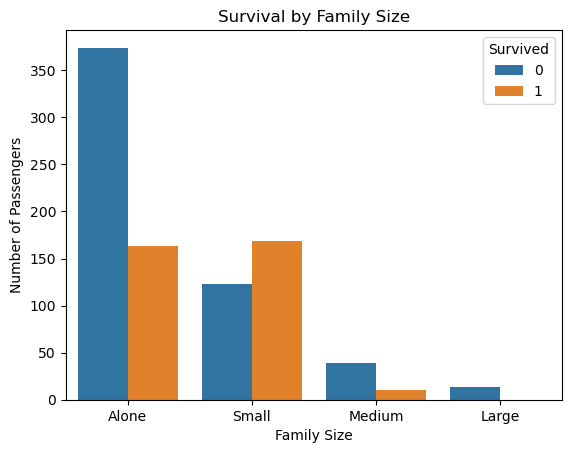

In [61]:
sns.countplot(
    data=df,
    x="Family_size_group",
    hue="Survived"
)

plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.show()

In [62]:
numeric_cols = [
    "Survived",
    "Ticket_class",
    "Age",
    "SibSp",
    "No_Children_Siblings_onboard",
    "Passenger_fare",
    "Family_size"
]

df[numeric_cols].corr()

,Survived,Ticket_class,Age,SibSp,No_Children_Siblings_onboard,Passenger_fare,Family_size
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Ticket_class,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
No_Children_Siblings_onboard,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Passenger_fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
Family_size,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000
